/tmp/ipykernel_14151/3432434845.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


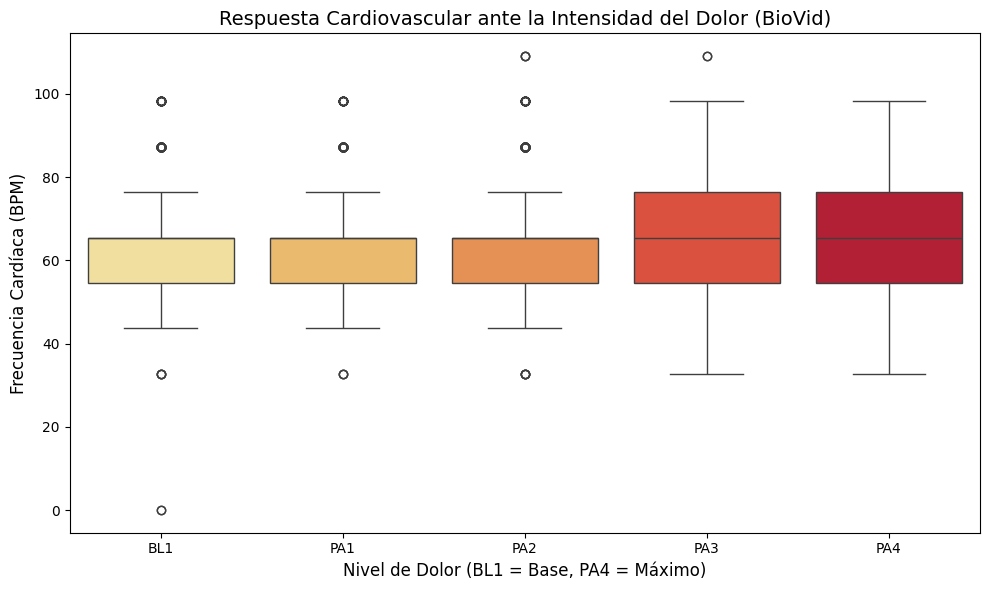

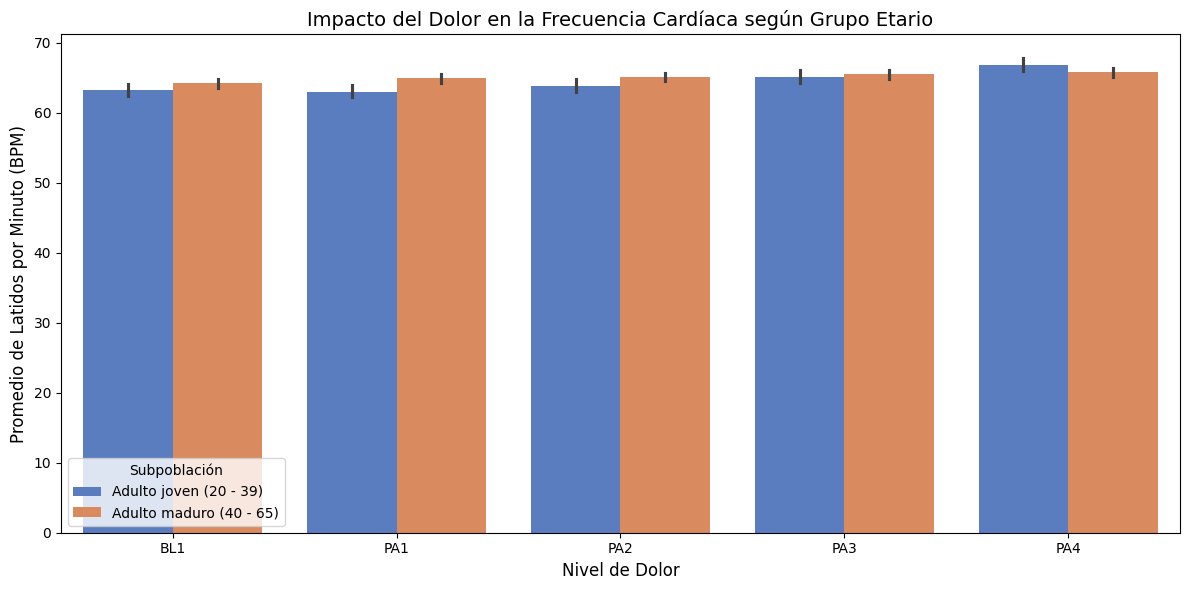

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Configurar estilo visual limpiosns.set_theme(style="ticks")

#Rectificar ruta del dataset IMPORTANTE
df_biovid = pd.read_csv('/content/drive/Shareddrives/DATA_GPI/Nuestros Datasets/dataset_features_biovid.csv')

#Se toma la edad de la columna 'subjet_name' que sigue este formato XXXXXX_x_EDAD y se crea la columna 'age'
df_biovid['age'] = df_biovid['subject_name'].str.split('_').str[+2].astype(int)
#Al aplicar la funcion .split() va a retornar un array con 3 posiciones [XXXXXX], [x], [EDAD] con el +2 iremos directo a la edad y se transforma en entero

#Se crea la columna 'age_group' para clasificarlos segun edad
df_biovid['age_group'] = np.where(df_biovid['age'] < 40, 'Adulto joven (20 - 39)', 'Adulto maduro (40 - 65)')




# ── Gráfico 1: Boxplot ECG por nivel de dolor ───────────────────────
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='class_name', y='ecg_bpm',
    data=df_biovid, palette='YlOrRd',
    order=['BL1', 'PA1', 'PA2', 'PA3', 'PA4']
)
plt.title('Respuesta Cardiovascular ante la Intensidad del Dolor (BioVid)', fontsize=14)
plt.xlabel('Nivel de Dolor (BL1 = Base, PA4 = Máximo)', fontsize=12)
plt.ylabel('Frecuencia Cardíaca (BPM)', fontsize=12)
plt.tight_layout()
plt.savefig('boxplot_ecg_dolor.png', dpi=150)
plt.show()

# ── Gráfico 2: Barplot ECG por nivel de dolor y grupo etario ────────
plt.figure(figsize=(12, 6))
sns.barplot(
    x='class_name', y='ecg_bpm',
    hue='age_group',
    data=df_biovid, palette='muted',
    order=['BL1', 'PA1', 'PA2', 'PA3', 'PA4']
)
plt.title('Impacto del Dolor en la Frecuencia Cardíaca según Grupo Etario', fontsize=14)
plt.xlabel('Nivel de Dolor', fontsize=12)
plt.ylabel('Promedio de Latidos por Minuto (BPM)', fontsize=12)
plt.legend(title='Subpoblación')
plt.tight_layout()
plt.savefig('barplot_ecg_grupo_etario.png', dpi=150)
plt.show()




